# Esame Laboratorio di Programmazione II - 03/02/2026


Scrivete chiaramente sul notebook il vostro nome e matricola e salvate il file con il nome della vostra matricola.

Per ogni funzione e metodo che richiede un campionamento rispetto ad una distribuzione settate il seed a 0: ``np.random.seed(0)``.

Stampate il risultato delle domanda e consegnate il compito eseguito, ogni cella deve avere il corrispondente output.
Quindi ad esempio

e.g., 
NON scrivete: 
```python 
    lista=np.array([1,2,3])
```
ma 
```python
    lista=np.array([1,2,3]) 
    print('lista =', lista)   
```
Attenzione!Se scrivete:
```python
    lista=np.array([1,2,3])
    lista
```
``lista`` sarà l'unico ouput che si vede di quella cella

NB se l'output è una matrice molto grande non dovete stamparla.

Sarà valutata anche la presentazione, ad esempio un plot senza ettichette sugli assi o illleggibili sarà valutato meno bene di uno con ettichette chiare.

Commentate il compito di modo che si capisca cosa avete fatto.

Controllate attentamente di avere consegnato il file giusto.

## Esercizio 1

Un sensore ha registrato le seguenti misure (in unità arbitrarie) in 15 istanti consecutivi:

`12, 15, 14, 18, 21, 19, 17, 16, 22, 25, 20, 18, 16, 15, 14`

1. Crea un array NumPy `x` con questi valori e calcola la **media**.
2. Per un problema di calibrazione, tutte le misure **strettamente maggiori di 18** devono essere **ridotte di 2**. Aggiorna l’array (in-place) e stampa il nuovo array.  
3. Calcola quanti valori, dopo la correzione, risultano **compresi tra 14 e 18 inclusi**.  


In [4]:
import numpy as np

# 1. Array e media
x = np.array ([12, 15, 14, 18, 21, 19, 17, 16, 22, 25, 20, 18, 16, 15, 14])
print ("PUNTO 1:")
print (f"- Media: {x.mean():.2f}")


# 2. Riduco di 2 le misure > 18
x [x > 18] -= 2
print ("\nPUNTO 2:")
print ("- Array dopo riduzione:", x.tolist())


# 3. Conto valori tra 14 e 18 inclusi
contati = np.sum ((x >= 14) & (x <= 18))
print ("\nPUNTO 3:")
print (f"- Valori tra 14 e 18 inclusi: {contati}")


PUNTO 1:
- Media: 17.47

PUNTO 2:
- Array dopo riduzione: [12, 15, 14, 18, 19, 17, 17, 16, 20, 23, 18, 18, 16, 15, 14]

PUNTO 3:
- Valori tra 14 e 18 inclusi: 11


## Esercizio 2

Un dado **truccato** ha probabilità **doppia** di uscire 6 rispetto agli altri numeri.

In particolare:
- la probabilità di ottenere ciascun numero da **1 a 5** è **1/7**
- la probabilità di ottenere **6** è **2/7**

1. Scrivi una funzione `lanci_dado(N)` che simula `N` lanci del dado e restituisce
   un array NumPy contenente i risultati.
2. Per valori di `N = 50, 100, 150, ..., 500`, esegui una simulazione e calcola
   la **frequenza relativa** del valore **6** e del valore **1**.
3. Rappresenta graficamente le frequenze relative del 6 e dell’1 in funzione di `N`
   e confrontale con i valori teorici.


PUNTO 1: Esempio con 10 lanci = [4, 6, 5, 4, 3, 5, 4, 6, 6, 3]

PUNTO 2: Frequenze relative
N =  50 → freq(6) = 0.2400, freq(1) = 0.1600
N = 100 → freq(6) = 0.2500, freq(1) = 0.1700
N = 150 → freq(6) = 0.3000, freq(1) = 0.1467
N = 200 → freq(6) = 0.2700, freq(1) = 0.1300
N = 250 → freq(6) = 0.2440, freq(1) = 0.1760
N = 300 → freq(6) = 0.3200, freq(1) = 0.1333
N = 350 → freq(6) = 0.3200, freq(1) = 0.1571
N = 400 → freq(6) = 0.3200, freq(1) = 0.1425
N = 450 → freq(6) = 0.2822, freq(1) = 0.1467
N = 500 → freq(6) = 0.2960, freq(1) = 0.1260

PUNTO 3: Grafico


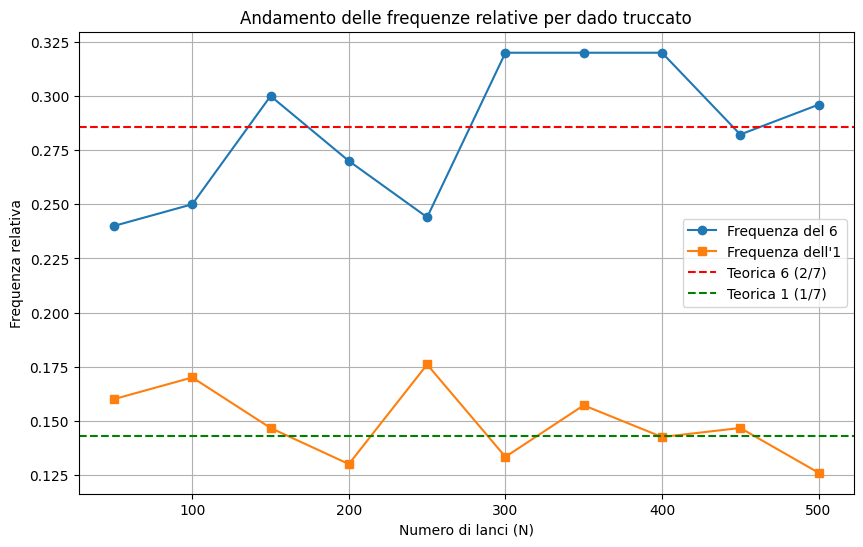

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# 1. Funzione che simula N lanci
def lanci_dado(N):
    p = [1/7, 1/7, 1/7, 1/7, 1/7, 2/7]          # Probabilità: 1-5 → 1/7 ciascuno, 6 → 2/7
    return np.random.choice([1, 2, 3, 4, 5, 6], size=N, p=p)

np.random.seed(0)
print ("PUNTO 1: Esempio con 10 lanci =", lanci_dado(10).tolist())



# 2. Frequenze relative per N = 50,100,...,500
N_values = list(range(50, 501, 50))
freq_6 = []
freq_1 = []

for N in N_values:
    risultati = lanci_dado(N)
    freq_6.append(np.sum(risultati == 6) / N)
    freq_1.append(np.sum(risultati == 1) / N)

print ("\nPUNTO 2: Frequenze relative")
for i, N in enumerate(N_values):
    print(f"N = {N:3d} → freq(6) = {freq_6[i]:.4f}, freq(1) = {freq_1[i]:.4f}")



# 3. Grafico
print ("\nPUNTO 3: Grafico")
plt.figure(figsize=(10,6))
plt.plot(N_values, freq_6, marker='o', label='Frequenza del 6')
plt.plot(N_values, freq_1, marker='s', label='Frequenza dell\'1')
plt.axhline(y=2/7, color='r', linestyle='--', label='Teorica 6 (2/7)')
plt.axhline(y=1/7, color='g', linestyle='--', label='Teorica 1 (1/7)')
plt.xlabel('Numero di lanci (N)')
plt.ylabel('Frequenza relativa')
plt.title('Andamento delle frequenze relative per dado truccato')
plt.legend()
plt.grid(True)
plt.show()



## Esercizio 3

Si consideri la seguente matrice di dimensione **4 × 5**, che rappresenta misure
raccolte in **4 giorni consecutivi** (righe) e in **5 fasce orarie** (colonne):

|     | F1 | F2 | F3 | F4 | F5 |
|-----|----|----|----|----|----|
| G1  | 12 | 15 | 14 | 16 | 18 |
| G2  | 11 | 14 | 13 | 15 | 17 |
| G3  | 13 | 16 | 15 | 17 | 19 |
| G4  | 10 | 13 | 12 | 14 | 16 |


1. Crea la matrice `M` come array NumPy e calcola:
   - la media di ciascuna riga
   - la media di ciascuna colonna
2. Crea una nuova matrice `N` ottenuta sottraendo a ogni elemento di `M`
   la media della **sua colonna**.
3. Individua la posizione (riga, colonna) del valore massimo di `N`
   e stampala.



In [11]:
import numpy as np


# 1. Creo matrice e calcolo medie
M = np.array([
    [12, 15, 14, 16, 18],
    [11, 14, 13, 15, 17],
    [13, 16, 15, 17, 19],
    [10, 13, 12, 14, 16]
])

print ("PUNTO 1:")
print (f"- Media di ogni riga: {M.mean(axis=1).round(2).tolist()}")
print (f"- Media di ogni colonna: {M.mean(axis=0).round(2).tolist()}")



# 2. Sottraggo la media della colonna
media_colonne = M.mean(axis=0)
N = M - media_colonne
print ("\nPUNTO 2: matrice N (prime 2 righe):")
print (N[:2])



# 3. Posizione del valore massimo di N
max_val = np.max(N)
pos = np.argmax(N)
riga, colonna = divmod(pos, N.shape[1])
print("\nPUNTO 3:")
print(f"- Valore massimo di N: {max_val:.2f} alla posizione (riga {riga}, colonna {colonna})")

PUNTO 1:
- Media di ogni riga: [15.0, 14.0, 16.0, 13.0]
- Media di ogni colonna: [11.5, 14.5, 13.5, 15.5, 17.5]

PUNTO 2: matrice N (prime 2 righe):
[[ 0.5  0.5  0.5  0.5  0.5]
 [-0.5 -0.5 -0.5 -0.5 -0.5]]

PUNTO 3:
- Valore massimo di N: 1.50 alla posizione (riga 2, colonna 0)


In [16]:
# =========================
# (Setup) creazione dataset
# =========================
### Creazione del dataset `students.csv` (da eseguire una sola volta)

def make_shipments_csv(filename="shipments.csv", n=80, seed=0):
    rng = np.random.default_rng(seed)

    shipment_id = [f"S{1000+i}" for i in range(n)]
    carrier = rng.choice(["AdriaticLog", "NordCargo", "BlueRail", "FastShip"], size=n, p=[0.35, 0.25, 0.25, 0.15])
    month = rng.choice([f"2025-{m:02d}" for m in range(1, 13)], size=n)

    weight_kg = rng.integers(200, 5000, size=n)
    distance_km = rng.integers(50, 1800, size=n)
    fuel_l = (distance_km / rng.uniform(4.5, 8.5, size=n)).round(2)   # litri consumati
    delay_days = rng.integers(-1, 8, size=n)                          # -1 = in anticipo
    on_time = (delay_days <= 0).astype(int)

    df = pd.DataFrame({
        "shipment_id": shipment_id,
        "carrier": carrier,
        "month": month,
        "weight_kg": weight_kg,
        "distance_km": distance_km,
        "fuel_l": fuel_l,
        "delay_days": delay_days,
        "on_time": on_time
    })

    # sporco il dataset con mancanti
    miss1 = rng.choice(df.index, size=max(1, n//20), replace=False)
    miss2 = rng.choice(df.index.difference(miss1), size=max(1, n//20), replace=False)
    df.loc[miss1, "fuel_l"] = np.nan
    df.loc[miss2, "delay_days"] = np.nan

    df.to_csv(filename, index=False)
    return df

df = make_shipments_csv("shipments.csv", n=80, seed=0)
print(df.head())

  shipment_id      carrier    month  weight_kg  distance_km  fuel_l  \
0       S1000     BlueRail  2025-11       3320          883  152.80   
1       S1001  AdriaticLog  2025-10       1852          716  136.38   
2       S1002  AdriaticLog  2025-05       1285          804  111.82   
3       S1003  AdriaticLog  2025-06       2265          802  151.88   
4       S1004     BlueRail  2025-06       4391          599   87.95   

   delay_days  on_time  
0         2.0        0  
1         3.0        0  
2         3.0        0  
3         5.0        0  
4         3.0        0  


# Esercizio 4

Si consideri il file CSV `shipments.csv`, che contiene informazioni su alcune spedizioni.
Il dataset presenta valori mancanti e diverse variabili quantitative e categoriche.

Svolgere le seguenti richieste:

1. Caricare il dataset in un DataFrame pandas e determinare il numero di valori mancanti per ciascuna colonna.
2. Eliminare dal dataset tutte le righe che contengono almeno un valore mancante.
3. Creare una nuova colonna `eff_km_per_l`, definita come il rapporto tra `distance_km` e `fuel_l`.
4. Filtrare le spedizioni con `weight_kg > 2500` e `eff_km_per_l > 6.5` e stampare il numero di righe ottenute.
5. Rappresentare con un grafico a barre le 10 spedizioni con il valore più alto di `eff_km_per_l`.

PUNTO 1:
- Dimensioni: (80, 8)
- Valori mancanti per colonna:
 shipment_id    0
carrier        0
month          0
weight_kg      0
distance_km    0
fuel_l         4
delay_days     4
on_time        0
dtype: int64

PUNTO 2: Dimensioni dopo dropna: (72, 8)

PUNTO 3: Prime 3 righe con efficienza:
  shipment_id  distance_km  fuel_l  eff_km_per_l
0       S1000          883  152.80      5.778796
1       S1001          716  136.38      5.250037
2       S1002          804  111.82      7.190127

PUNTO 4: Spedizioni con peso > 2500 e efficienza > 6.5: 20
   shipment_id  weight_kg  eff_km_per_l
4        S1004       4391      6.810688
5        S1005       4837      6.908924
13       S1013       4462      7.403205

PUNTO 5: Grafico a barre


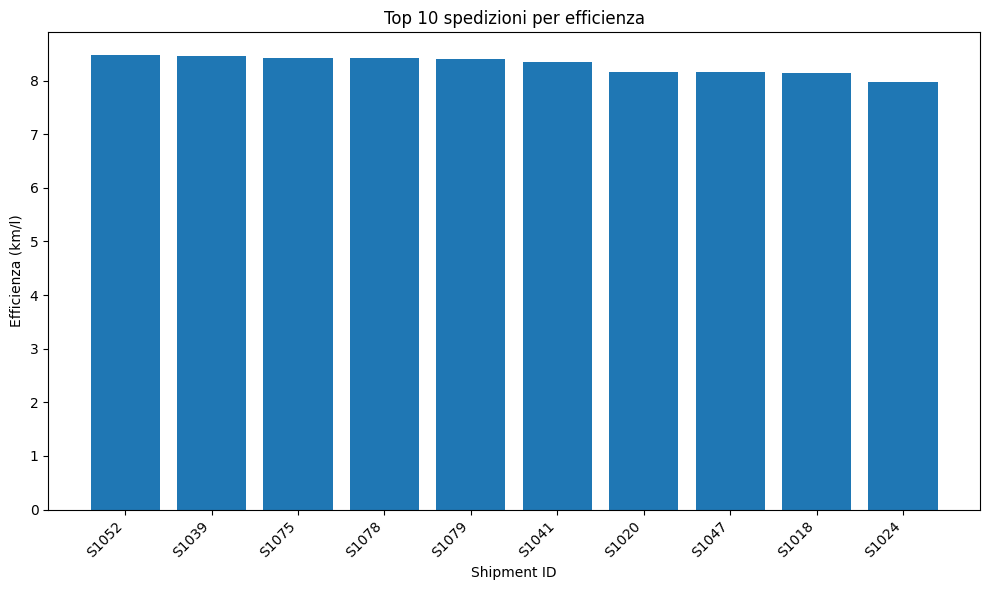

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Carico e conto valori mancanti
df = pd.read_csv('shipments.csv')
print ("PUNTO 1:")
print (f"- Dimensioni: {df.shape}")
print ("- Valori mancanti per colonna:\n", df.isnull().sum())

# 2. Elimino righe con NaN
df = df.dropna()
print ("\nPUNTO 2: Dimensioni dopo dropna:", df.shape)

# 3.  Nuova colonna efficienza
df['eff_km_per_l'] = df['distance_km'] / df['fuel_l']
print ("\nPUNTO 3: Prime 3 righe con efficienza:")
print (df[['shipment_id', 'distance_km', 'fuel_l', 'eff_km_per_l']].head(3))

# 4. Filtro
filtro = df[(df['weight_kg'] > 2500) & (df['eff_km_per_l'] > 6.5)]
print (f"\nPUNTO 4: Spedizioni con peso > 2500 e efficienza > 6.5: {len(filtro)}")
if len (filtro) > 0:
    print (filtro[['shipment_id', 'weight_kg', 'eff_km_per_l']].head(3))

# 5. Grafico a barre top 10 efficienza
top10 = df.nlargest(10, 'eff_km_per_l')
print ("\nPUNTO 5: Grafico a barre")
plt.figure(figsize=(10,6))
plt.bar(top10['shipment_id'].astype(str), top10['eff_km_per_l'])
plt.xlabel('Shipment ID')
plt.ylabel('Efficienza (km/l)')
plt.title('Top 10 spedizioni per efficienza')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Esercizio 5

Si utilizzi lo stesso dataset `shipments.csv`, opportunamente pulito come nell’esercizio precedente.

Svolgere le seguenti richieste:

1. Determinare il numero di righe e di colonne del dataset ed eliminare la colonna `shipment_id`.
2. Individuare il `carrier` più frequente nel dataset.
3. Calcolare la media di `delay_days` per ciascun `carrier` e ordinare i risultati dal valore medio più alto al più basso.
4. Rappresentare la distribuzione di `delay_days` per ciascun `carrier` mediante un boxplot.
5.  Calcolare la percentuale di spedizioni puntuali (`on_time = 1`) e non puntuali (`on_time = 0`)
**usando una list comprehension**, e rappresentare tali percentuali con un grafico a torta (pie chart).


PUNTO 1:
- Righe: 72, Colonne: 8
- Colonne dopo eliminazione: 7

PUNTO 2:
- Carrier più frequente: AdriaticLog

PUNTO 3:
carrier
AdriaticLog    3.653846
BlueRail       3.166667
FastShip       3.166667
NordCargo      2.750000
Name: delay_days, dtype: float64

PUNTO 4: Boxplot


<Figure size 1000x600 with 0 Axes>

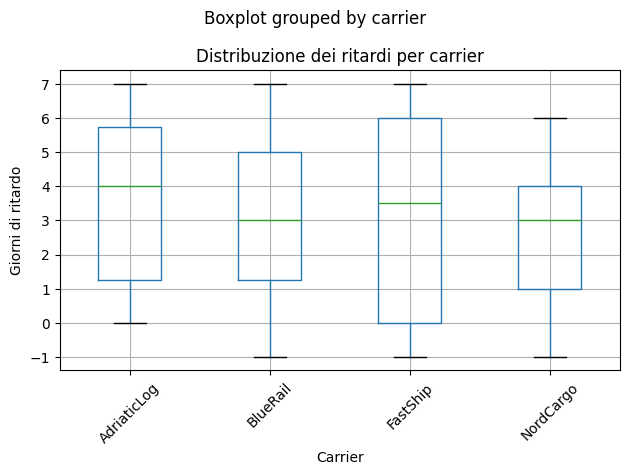


PUNTO 5:
- Percentuale spedizioni puntuali (on_time=1): 16.7%
- Percentuale spedizioni non puntuali (on_time=0): 83.3%


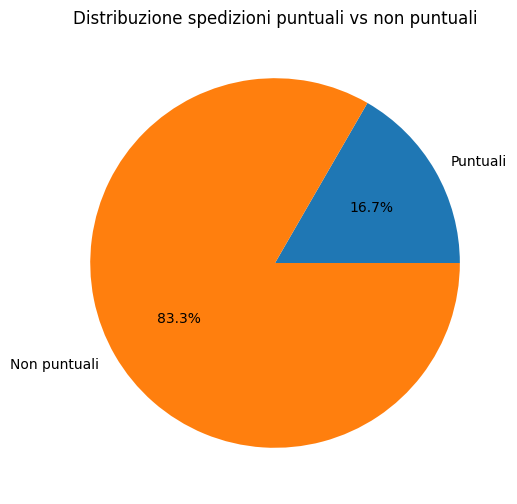

In [28]:
import pandas as pd
import matplotlib.pyplot as plt


# 1. Dimensioni ed elimino colonna shipment_id
df = pd.read_csv('shipments.csv')                           # Carico
df = df.dropna()                                            # Pulisco i NaN
print ("PUNTO 1:")
print (f"- Righe: {df.shape[0]}, Colonne: {df.shape[1]}")

df = df.drop(columns=['shipment_id'])                       # Elimino colonna
print (f"- Colonne dopo eliminazione: {df.shape[1]}")


# 2. Carrier più frequente
carrier_freq = df['carrier'].value_counts().idxmax()
print ("\nPUNTO 2:")
print (f"- Carrier più frequente: {carrier_freq}")


# 3. Media delay_days per carrier 
media_delay = df.groupby('carrier')['delay_days'].mean().sort_values(ascending=False)
print ("\nPUNTO 3:")
print (media_delay)


# PUNTO 4. Boxplot dei ritardi per carrier
print("\nPUNTO 4: Boxplot")
plt.figure(figsize=(10,6))
df.boxplot(column='delay_days', by='carrier')
plt.xlabel('Carrier')
plt.ylabel('Giorni di ritardo')
plt.title('Distribuzione dei ritardi per carrier')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 5. Percentuali on_time con list comprehension
on_time_list = [1 if val == 1 else 0 for val in df['on_time']]
on_time_pct = sum(on_time_list) / len(on_time_list) * 100
off_time_pct = 100 - on_time_pct

print ("\nPUNTO 5:")
print (f"- Percentuale spedizioni puntuali (on_time=1): {on_time_pct:.1f}%")
print (f"- Percentuale spedizioni non puntuali (on_time=0): {off_time_pct:.1f}%")

# Grafico a torta
plt.figure(figsize=(6,6))
plt.pie([on_time_pct, off_time_pct], labels=['Puntuali', 'Non puntuali'], autopct='%1.1f%%')
plt.title('Distribuzione spedizioni puntuali vs non puntuali')
plt.show()

## Esercizio 6

Hai a disposizione il dataset di coppie `(x, y)` qui sotto riportato.  

1. Stima i parametri della retta del tipo  

   $$
   y = a \cdot x + b
   $$  

2. Plotta i punti originali e la retta ottenuta.  

3. Calcola **MAE** (Mean Absolute Error) e **RMSE** (Root Mean Squared Error) tra i valori reali `y` e quelli stimati dal modello, dove:  

   $$
   \text{MAE} = \frac{1}{n}\sum_{i=1}^{n} \lvert y_i - \hat{y}_i \rvert
   $$  

   $$
   \text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
   $$


PUNTO 1:
- Parametri stimati: a = 3.6205, b = 0.8307

PUNTO 2: Grafico


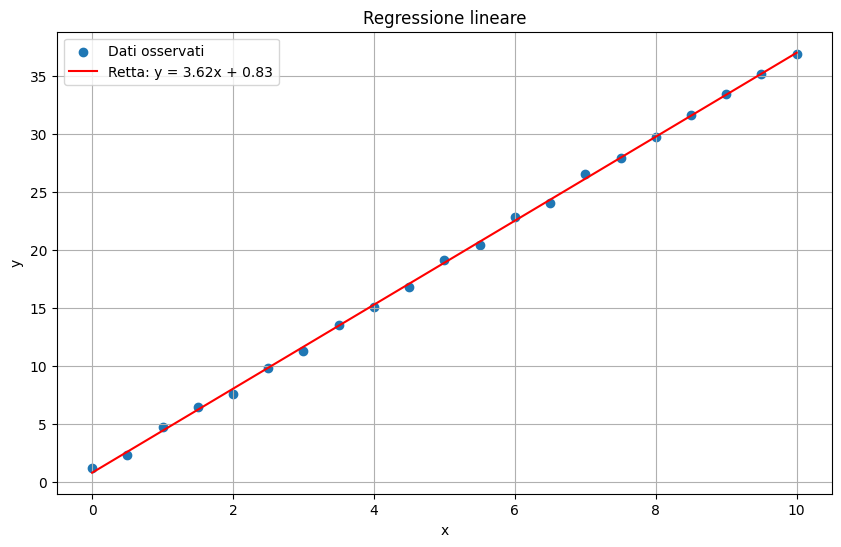


PUNTO 3:
- MAE  = 0.2200
- RMSE = 0.2624


In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Dati forniti
x = np.array([
   0.0, 0.5, 1.0, 1.5, 2.0, 2.5,
   3.0, 3.5, 4.0, 4.5, 5.0, 5.5,
   6.0, 6.5, 7.0, 7.5, 8.0, 8.5,
   9.0, 9.5, 10.0
])

y = np.array([
   1.2,  2.4,  4.8,  6.5,  7.6,  9.9,
  11.3, 13.6, 15.1, 16.8, 19.2, 20.5,
  22.9, 24.1, 26.6, 28.0, 29.8, 31.7,
  33.5, 35.2, 36.9
])


# 1. Stima parametri
def modello_lineare(x, a, b):
    return a * x + b

popt, _ = curve_fit(modello_lineare, x, y)
a, b = popt
print ("PUNTO 1:")
print (f"- Parametri stimati: a = {a:.4f}, b = {b:.4f}")



# 2. Plot punti e retta
print ("\nPUNTO 2: Grafico")
y_pred = modello_lineare(x, a, b)
plt.figure(figsize=(10,6))
plt.scatter(x, y, label='Dati osservati')
plt.plot(x, y_pred, 'r-', label=f'Retta: y = {a:.2f}x + {b:.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Regressione lineare')
plt.legend()
plt.grid(True)
plt.show()


# 3. MAE e RMSE
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
print ("\nPUNTO 3:")
print (f"- MAE  = {mae:.4f}")
print (f"- RMSE = {rmse:.4f}")